# Backprop with a neuron function

## with a mathematical model of a single nueron we are trying to learn back propagration

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

#this line of code will show the graphs inside of the notebook, its jp notebook specific:-
%matplotlib inline 

## Value class
- the reason we are implementing this class is basically to keep a track of what operations led us to the result 
- simply said , we are traking the previous nodes of the tree , and the tree itself is the arithmatic equation 
- we are also storing the gradient of the loss function, with respect to each node 
- the main benifit of using this data structre is that we can back propogate through the computation graph, to find out how each node influences the loss function 
### Nuances of the Value class 
- using += is really important cuase of the accumulation property of the chain rule, this only shows up when onve var is used multiple times 
- when adding/multiplying an integer/float we are simply checking if the var is an instance of Value, if its not then we wrap the var in a Value obj
- __rmul__ would check if the objs could be mutiplied in the other direction , ex:- 2*a = a*2
- the exp function is pretty simply as local derivative of the e^x =e^x
- here instead of conventional division we are using = a * (b^(-1)) = (a*(1/b)) = a/b
- here since the __truediv__ method uses a power we would be treating the power as a node in the computational graph 
- the __pow__ method is only supporting int/float powers for now, if raises and error in the power is not a int/float
- once the power is set to a int/float , we only need to find the local var and chain it , and here the local var is x^n = n*x^(n-1)

In [2]:
class Value:
    
    def __init__(self, data, _children=(), _op='' , label=''):
         self.data = data
         self.prev = set(_children)
         self.op = _op
         self.label = label
         self.grad = 0  
         self._backward = lambda: None
         
    def __repr__(self):
         return f"Value(data={self.data})"
    
    def __add__(self, other):    
          if isinstance(other, Value) == False:
             other = Value(other) 
          out = Value(self.data + other.data, (self,other), '+')   
          def _backward():
               self.grad += 1 * out.grad 
               other.grad += 1 * out.grad   
          out._backward = _backward     
          return out 
     
    def __sub__(self, other): # this would although use the upper add function, we get the thing done by doing = self - other
        return self + (-other)

    def __neg__(self):
         return self * -1   #this will be using multiplication function, but we still get it done by negating the number (-self)

    def __mul__(self, other):
          if isinstance(other, Value) == False:
             other = Value(other)  
          out = Value(self.data * other.data, (self,other), '*') 
          def _backward():
               self.grad += other.data * out.grad
               other.grad += self.data * out.grad
          out._backward = _backward          
          return out
     
    def __rmul__(self, other):
          return self * other
     
    def __pow__(self, other):
          assert isinstance(other , (int, float)) , 'only supporting int/float powers for now'   #this is a gaurd claude in python works if not condition then raise a AssertionError
          out = Value(self.data**other, (self, ), f'**{other}')
          
          def _backward():
               self.grad += other * (self.data**(other - 1)) * out.grad
          out._backward = _backward
          return out
               
    def __truediv__(self, other): #self/other = self * other**-1
         return self * other**-1
      
    def exp(self):
         x = self.data
         out = Value(math.exp(x), (self, ), 'exp') 
         
         def _backward():
              self.grad += out.data * out.grad
         out._backward = _backward
         return out      
     
    def tanh(self):
         x=self.data
         t=(math.exp(2*x) -1)/(math.exp(2*x)+1)
         output = Value(t, (self, ), 'tanh')
         def _backward():     
               self.grad += (1-t**2)*output.grad
         output._backward = _backward    
         return output
    
    def backward(self):
     topo = []
     visited = set()
     def build_topo(v):
          if v not in visited:
               visited.add(v)
               for child in v.prev:
                    build_topo(child)
               topo.append(v)
     build_topo(self)    
     
     self.grad = 1
     for node in reversed(topo):
          node._backward()

## Code to draw the computional graph
- We are doing a DFS graph traversal to draw each node

In [3]:
from graphviz import Digraph

def trace(root):
    """Build a set of all nodes and edges in the graph."""
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # value node (rounded box)
        dot.node(uid, label=f"{{ {n.label} | data: {n.data:.4f} | grad: {n.grad:.4f} }}", shape='record')
        # if this value was produced by an op, create an op node
        if n.op:
            op_uid = uid + n.op
            dot.node(op_uid, label=n.op)
            dot.edge(op_uid, uid)

    for n1, n2 in edges:
        # connect n1 to n2's op node
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)

    return dot

## One atomic Neuron
- This is the mathematical forumula of one single neuron
- We are packing the neuron formula in a non linear tanh function
- instead of a using a tanh function, which is composite we can also break up tanh into atomic components
- tanh = (e^(2x)-1)/(e^(2x)+1)
- It doesnt actually matter if we take a composite function or break up the function further, as long as we can find the local derivative of the function we should be good to go 

In [13]:

# inputs are x and y
x=Value(2.0, label = 'x')
y=Value(0.0, label='y')

#weights w1, w2
w1=Value(-3.0, label = 'w1')
w2=Value(1.0, label = 'w2')

#bias of the neuron
b = Value(8, label = 'b')

xw1=x*w1 ; xw1.label='x.w1'
yw2=y*w2 ; yw2.label='y.w2'

sum = xw1 + yw2 ; sum.label = 'sum'

neuron = sum + b; neuron.label ='neuron'

#the neuron funtion:-
#output = neuron.tanh() ; output.label = 'output'

# here instead of tanh, we would be experimenting with tanh = (e^(2x)-1)/(e^(2x)+1)
two = Value(2.0, label='2')
result = two*neuron ; result.label='2*neuron' 
e = Value.exp(result) ; e.label = 'exp'
output = (e-1)/(e+1) ; output.label = 'output'

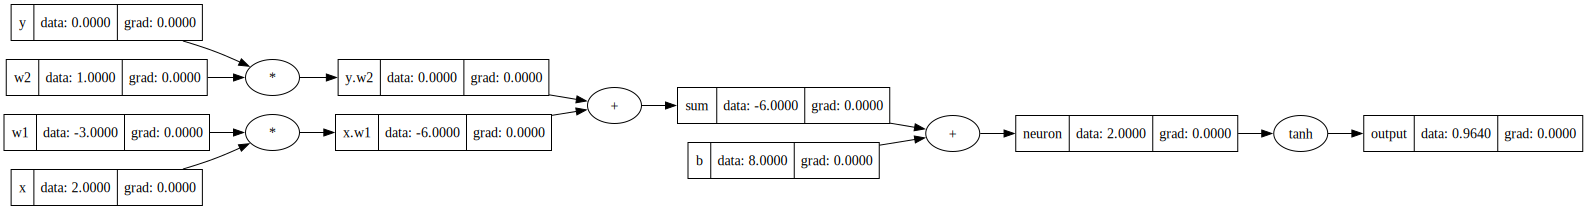

In [11]:
draw_dot(output)

## Here we would take a manual approach to fill up the gradients:-
- The last node here is the loss function and we would like to find the derivative of that function with respect to all its childdren 
- Basically we are trying to minimise the Loss function by back propagating through all the children nodes and computing the gradient to try adjust the weights, which would result in a minimised Loss function
- the dereivative of the last with respect to itself is 1.0
- the derivative of the output function with respect to neuron node(tanh(neuron)) = d_output/d_neuron = 1-(tanh(neuron))^2 = (1-output^2)
- now we use the chain rule to find the derivatives all the other nodes:-
    - starting with d_output/d_summation = d_output/d_neuron * d_neuron/d_summation = neuron.grad * 1(the the serivative of sum+b with respect to sum is 1)
    - d_output/d_b = d_output/d_neuron * d_neuron/d_b = neuron.grad * 1(the the serivative of sum+b with respect to b is 1) 
    - d_output/(d_x.w1) = d_output/d_sum * d_sum/d_x.w1 = sum.grad * 1
    - d_output/(d_y.w2) = d_output/d_sum * d_sum/d_y.w2 = sum.grad * 1
    - d_output/d_w1 = d_output/d_x.w1 * d_x.w1/d_w1 = xw1.grad * x
    - d_output/d_x  = d_output/d_x.w1 * d_x.w1/d_x = xw1.grad * w1
    - d_output/d_w2 = d_output/d_y.w2 * d_y.w2/d_w2 = yw2.grad * y
    - d_output/d_y = d_output/d_y.w2 * d_y.w2/d_y = yw2.grad * w2

In [6]:
output.grad = 1.0
neuron.grad = 1 - (output.data**2)
sum.grad = neuron.grad * 1
b.grad = neuron.grad * 1
xw1.grad = sum.grad * 1
yw2.grad = sum.grad * 1
w1.grad = xw1.grad * x.data
x.grad = xw1.grad * w1.data
w2.grad = yw2.grad * y.data
y.grad = yw2.grad * w2.data

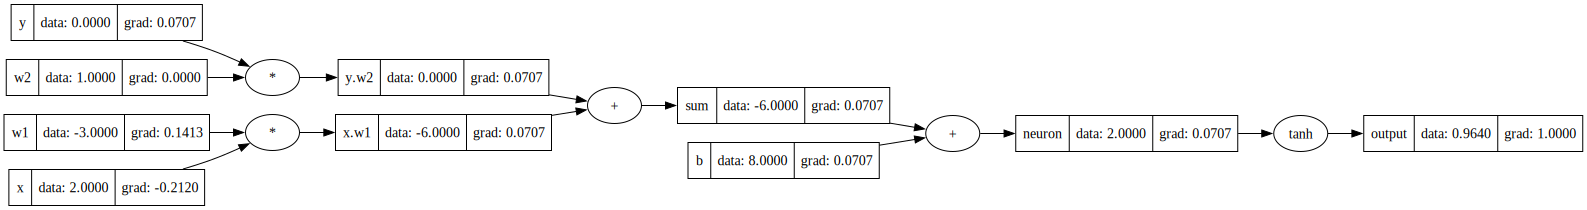

In [12]:
output.grad = 1
output.backward()
draw_dot(output)

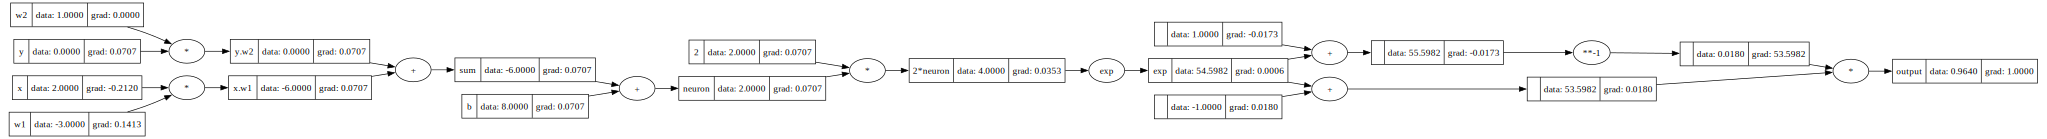

In [14]:
output.grad = 1
output.backward()
draw_dot(output)

## Using Pytorch
- Here we are doing the same thing as micrograd but using pytorch 
- Pytorch is a lib that pretty much does the same things that we manually implemented 
- The biggest benefit of pytorch is that it allows us to use GPU computation and also everything is Tensors(multi-dimensional vectors)
- we need eo explicitly specify that we would be needing to keep track of gradient , so that we can later back-prop

In [16]:
import torch

# same values as the micrograd neuron above (using t_ prefix to avoid shadowing)
x1  = torch.Tensor([2.0]).double().requires_grad_(True)   # x
x2  = torch.Tensor([0.0]).double().requires_grad_(True)   # y
w1t = torch.Tensor([-3.0]).double().requires_grad_(True)  # w1
w2t = torch.Tensor([1.0]).double().requires_grad_(True)   # w2
bt  = torch.Tensor([8.0]).double().requires_grad_(True)   # b

# forward pass — mirrors the micrograd computation exactly
x1w1    = x1 * w1t
x2w2    = x2 * w2t
neuron_t = x1w1 + x2w2 + bt

# tanh expanded form: (e^(2x) - 1) / (e^(2x) + 1)
e_t      = (2 * neuron_t).exp()
output_t = (e_t - 1) / (e_t + 1)

# backward pass
output_t.backward()

# compare PyTorch gradients vs micrograd gradients
print('         PyTorch      |    micrograd')
print(f'x  grad: {x1.grad.item():.4f}       |    {x.grad:.4f}')
print(f'y  grad: {x2.grad.item():.4f}       |    {y.grad:.4f}')
print(f'w1 grad: {w1t.grad.item():.4f}      |    {w1.grad:.4f}')
print(f'w2 grad: {w2t.grad.item():.4f}      |    {w2.grad:.4f}')
print(f'b  grad: {bt.grad.item():.4f}       |    {b.grad:.4f}')

         PyTorch      |    micrograd
x  grad: -0.2120       |    -0.2120
y  grad: 0.0707       |    0.0707
w1 grad: 0.1413      |    0.1413
w2 grad: 0.0000      |    0.0000
b  grad: 0.0707       |    0.0707
